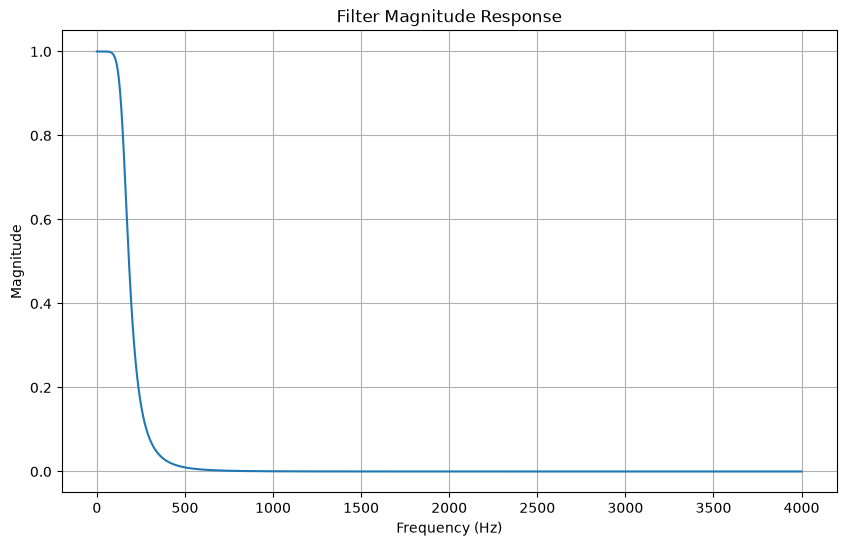

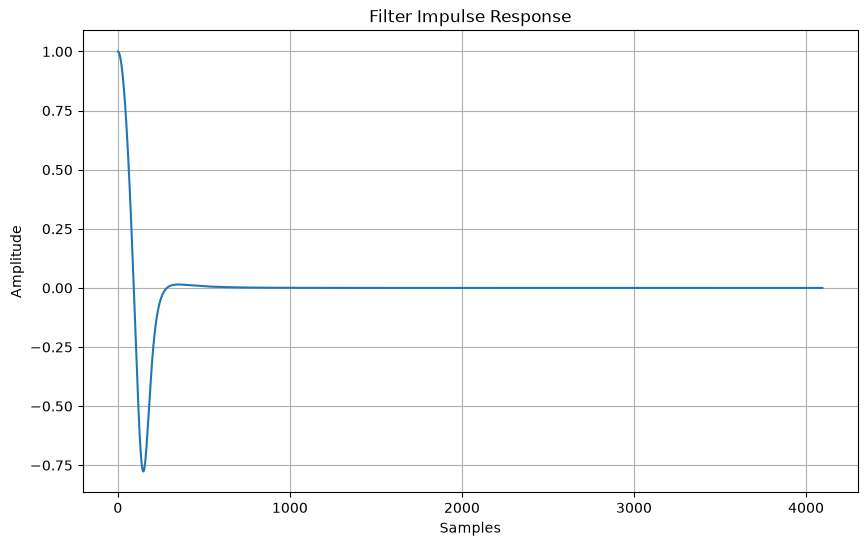

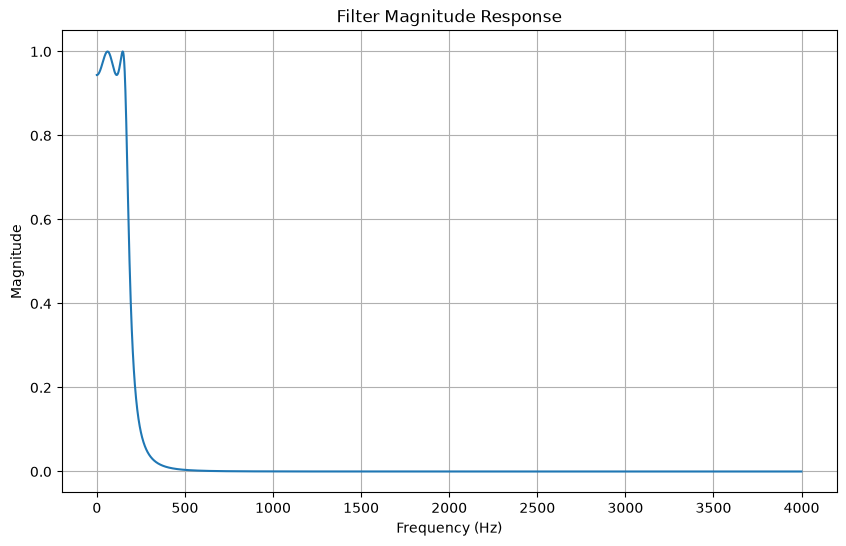

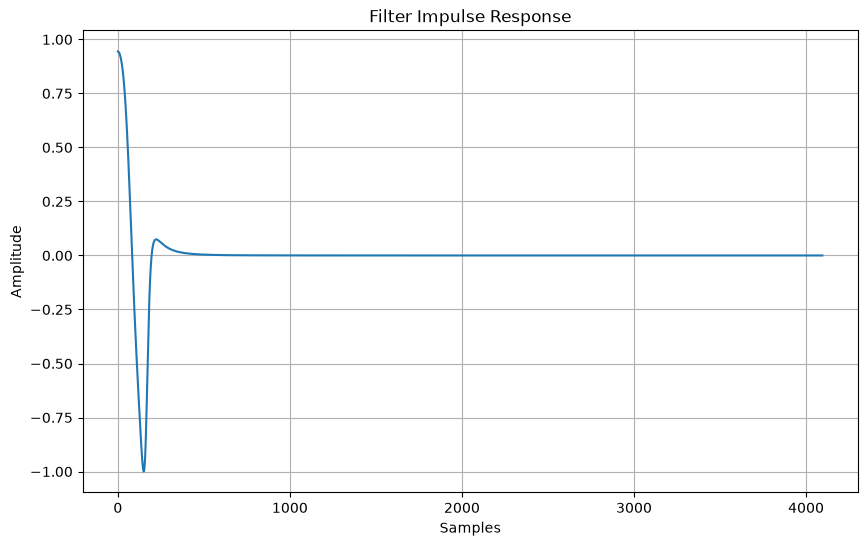

Filter coefficients saved at: filter_coefficients.txt


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, bilinear, freqz, cheby1

def design_butterworth_filter(filter_order, cutoff_frequency, sampling_frequency):
    # Design the analog Butterworth filter
    analog_b, analog_a = butter(
        filter_order,
        cutoff_frequency,
        analog=True,
        btype='low'
    )
    # Perform bilinear transformation
    digital_b, digital_a = bilinear(
        analog_b,
        analog_a,
        sampling_frequency
    )
    return digital_b, digital_a
def design_chebyshev_filter(
    filter_order,
    cutoff_frequency,
    sampling_frequency,
    ripple
):
    # Design the analog Chebyshev Type-I filter
    analog_b, analog_a = cheby1(
        filter_order,
        ripple,
        cutoff_frequency,
        analog=True,
        btype='low'
    )
    # Perform bilinear transformation
    digital_b, digital_a = bilinear(
        analog_b,
        analog_a,
        sampling_frequency
    )

    return digital_b, digital_a

def plot_filter_response(
    digital_b,
    digital_a,
    sampling_frequency
):
    # Compute frequency response
    frequency, response = freqz(
        digital_b,
        digital_a,
        fs=sampling_frequency,
        worN=4096
    )
    magnitude_response = np.abs(response)

    plt.figure(figsize=(10, 6))

    plt.plot(
        frequency,
        magnitude_response
    )

    plt.title('Filter Magnitude Response')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)

    plt.show()
    
    impulse_response = np.real(response)

    plt.figure(figsize=(10, 6))

    plt.plot(
        impulse_response
    )

    plt.title('Filter Impulse Response')
    plt.xlabel('Samples')
    plt.ylabel('Amplitude')
    plt.grid(True)

    plt.show()

filter_order = 4
cutoff_frequency = 1000    
sampling_frequency = 8000  
ripple = 0.5

digital_b, digital_a = design_butterworth_filter(
    filter_order,
    cutoff_frequency,
    sampling_frequency
)
# Plot Butterworth filter response
plot_filter_response(
    digital_b,
    digital_a,
    sampling_frequency
)

digital_b, digital_a = design_chebyshev_filter(
    filter_order,
    cutoff_frequency,
    sampling_frequency,
    ripple
)
# Plot Chebyshev filter response
plot_filter_response(
    digital_b,
    digital_a,
    sampling_frequency
)

filter_path = 'filter_coefficients.txt'

np.savetxt(
    filter_path,
    np.vstack((digital_b, digital_a)),
    delimiter=','
)

print(f"Filter coefficients saved at: {filter_path}")